In [1]:
%load_ext autoreload
%autoreload 2

# 2. Predicción de Rendimiento de Jugadores de Basketball
Los archivos WAR_class_dev.csv y WAR_class_test.csv tienen los datos de distintos jugadores de basketball recopilados a lo largode varias temporadas. Los features indican diversas métricas individuales para cada jugador. La variable objetivo es WAR_class, donde WAR son las siglas de una métrica llamada Wins Above Replacement (“Victorias Por Encima de Suplencias”), que mide el impacto de un jugador en términos de partidos ganados por encima de lo que aportaría un jugador suplente promedio.


El objetivo es desarrollar distintos modelos predictivos para estimar la probabilidad de que un jugador pertenezca a una de las tres clases definidas en la columna war_class: Negative WAR, Null WAR o Positive WAR, que corresponden a las clases 1, 2 y 3 respectivamente.

El resto de las features presentes están explicadas en el archivo WAR_class.md.

# 2.1
Conducir un análisis exploratorio sobre los datos en WAR_class_dev.csv. Visualice la distribución de las variables y de la variable objetivo. Verifique si hay valores faltantes (NaN), datos duplicados o desbalanceo entre clases. Analice también la posible presencia de correlaciones fuertes entre los features. (Pandas Cheat Sheet)

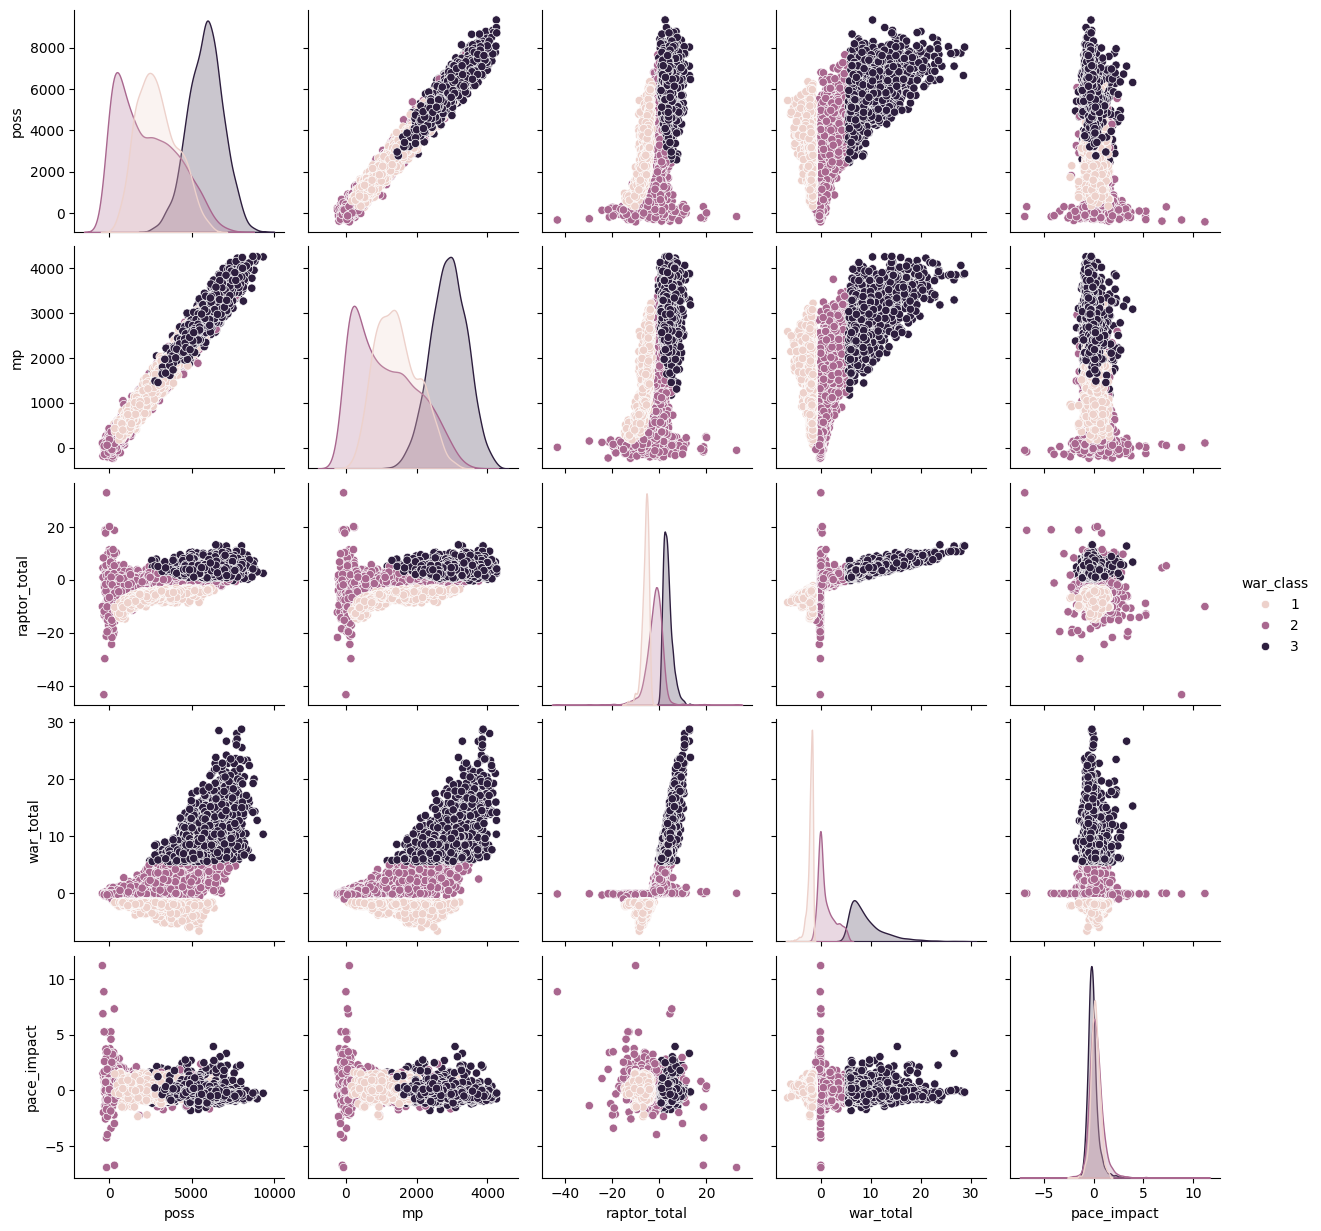

Cantidad de nans por columna:


,Cantidad de NaNs
poss,0
mp,0
raptor_total,0
war_total,0
pace_impact,0
war_class,0





Cantidad de filas duplicadas: 0
No hay filas duplicadas.


Columna 'poss': 0 valores duplicados
Columna 'mp': 0 valores duplicados
Columna 'raptor_total': 0 valores duplicados
Columna 'war_total': 0 valores duplicados
Columna 'pace_impact': 0 valores duplicados
Columna 'war_class': 6779 valores duplicados



Distribución de clases:


,Proporción
war_class,
2,0.369950
3,0.330876
1,0.299174


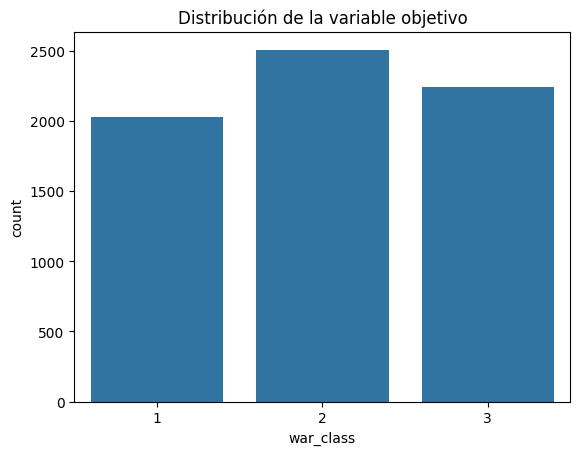

Mutual Information entre las características y la variable objetivo:


,Feature,Mutual Information
0,war_total,1.028034
1,raptor_total,0.701113
2,mp,0.441651
3,poss,0.433159
4,pace_impact,0.062873


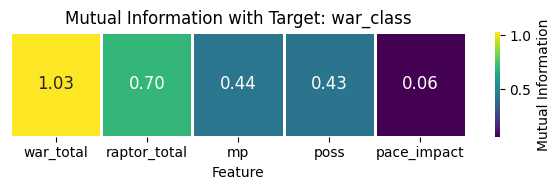

Mutual Information entre las características y la variable objetivo:


,Feature,Mutual Information
0,raptor_total,0.701113
1,mp,0.441651
2,poss,0.433159
3,pace_impact,0.062873


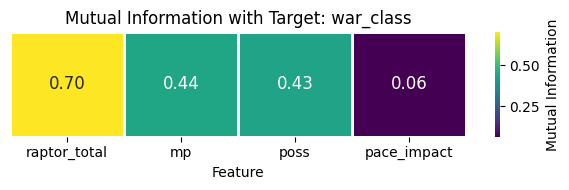

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6782 entries, 0 to 6781
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   poss          6782 non-null   float64
 1   mp            6782 non-null   float64
 2   raptor_total  6782 non-null   float64
 3   pace_impact   6782 non-null   float64
 4   war_class     6782 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 265.1 KB


,poss,mp,raptor_total,pace_impact,war_class
count,6782.000000,6782.000000,6782.000000,6782.000000,6782.000000
mean,3639.756160,1811.567736,-1.484226,0.091128,2.031702
std,2097.793568,1039.122355,4.667840,0.650618,0.793182
min,-414.390684,-235.333650,-43.449330,-6.935191,1.000000
25%,1913.845719,956.592966,-5.271681,-0.278206,1.000000
50%,3621.170163,1801.519616,-1.459043,0.022291,2.000000
75%,5377.166126,2670.373141,2.201138,0.389032,3.000000
max,9329.401575,4264.461247,32.904816,11.193450,3.000000


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import sys
sys.path.append('../../Problema 1/src')
from models import *
from preprocessing import *
from metrics import f1_score
from utils import get_feature_ranges
sys.path.append('../src')
from data_splitting_2 import *
from preprocessing_2 import *
from models_2 import *
from metrics_2 import *
from utils_2 import *

TARGET = 'war_class'

df = pd.read_csv('../data/raw/WAR_class_dev.csv')

# 1. Distribution of the variables and the target variable
sns.pairplot(df, diag_kind="kde", hue=TARGET)
plt.show()

# 2. Number of nans per column
nan_counts = df.isna().sum()
print("Cantidad de nans por columna:")
display(nan_counts.to_frame(name="Cantidad de NaNs"))
print("\n\n")

# 3. Duplicate data analysis
duplicates = df.duplicated().sum()
print(f"Cantidad de filas duplicadas: {duplicates}")
if duplicates > 0:
    print("Filas duplicadas:")
    display(df[df.duplicated()])
    print("\n\n")
else:
    print("No hay filas duplicadas.\n\n")
for col in df.columns:
    duplicated_count = df[col].duplicated().sum()
    print(f"Columna '{col}': {duplicated_count} valores duplicados")
print("\n\n")

# 4. Class imbalance analysis
class_counts = df['war_class'].value_counts(normalize=True)
print("Distribución de clases:")
display(class_counts.to_frame(name="Proporción"))
print("\n\n")
sns.countplot(x='war_class', data=df)
plt.title("Distribución de la variable objetivo")
plt.show()

# 5. Analysis of mutual information
calculate_mutual_information(df, target=TARGET)
df = df.drop(columns=['war_total'])
calculate_mutual_information(df, target=TARGET)


df.info()
display(df.describe())

{'poss': (np.float64(4.24), np.float64(9329.4)),
 'mp': (np.float64(0.23), np.float64(4264.46))}

,poss,mp,raptor_total,pace_impact,war_class
0,-0.678114,-0.985091,-0.403848,0.585699,2
1,-1.213059,-1.240295,-0.836539,2.269038,2
2,0.777560,0.564229,1.835655,-0.961291,3
3,1.908302,1.848062,1.503215,-1.231505,3
4,2.339598,1.940375,1.408249,-1.214635,3


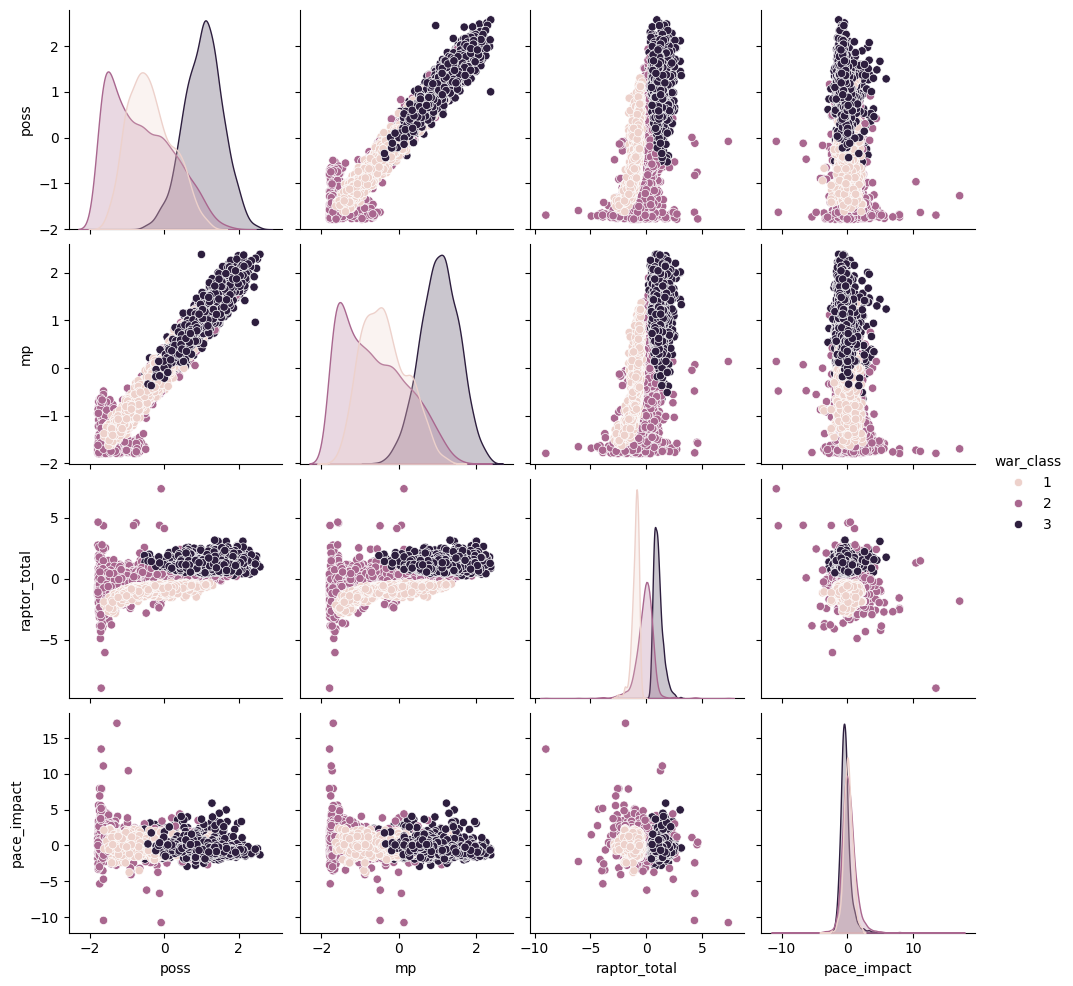

In [3]:
numeric_features = df.select_dtypes(include=[np.number])
categorical_columns = df.select_dtypes(include=['object', 'bool']).columns
feature_ranges = get_feature_ranges(df, numeric_features.drop(columns=[TARGET, 'pace_impact', 'raptor_total']), q1=0.1449, q3=0.7336)
display(feature_ranges)

df = process_data(df, categorical_columns, feature_ranges=feature_ranges, target=TARGET)

df.to_csv('../data/processed/WAR_class_dev_processed.csv', index=False)
display(df.head())

sns.pairplot(df, diag_kind="kde", hue=TARGET)
plt.show()

# 2.2
Implementar las siguientes tres arquitecturas, adecuadas para la tarea de clasificación:
1) Análisis discriminante lineal (Linear Discriminant Analysis, LDA).
2) Regresión logística multi-clase. Recuerde que puede agregar regularización.
3) Bosque aleatorio (Random Forest) utilizando la entropía como criterio de división. Se recomienda experimentar con diferentes configuraciones de hiperparámetros (número de árboles, profundidad máxima, etc.). Luego, se podrá seleccionar la mejor combinación en función de los resultados obtenidos.

Tanto LDA como Random Forest fueron implementados en el archivo models_2.py, y la regresión logística multi-clase en el archivo models.py utilizando la misma que en la sección 1.

# 2.3
Utilizando el conjunto de datos de desarrollo WAR_class_dev.csv entrene los modelos mencionados en el inciso anterior. Recuerde que estos modelos, en particular LDA y regresión logística, suelen obtener mejores resultados cuando se entrenan con datos normalizados. Utilice las técnicas de reescalado y data splits que considere más apropiadas. Para cada modelo desarrollado reporte la estimación de las siguientes métricas de performance.

WAR_class_dev.csv :

– Matriz de confusión
– Accuracy
– Precision
– Recall
– F-Score
– Curva Precision-Recall (PR)
– Curva ROC
– AUC-ROC
– AUC-PR

Presentar los resultados de manera compacta para facilitar la comparación entre los modelos.

{'poss': (np.float64(4.24), np.float64(9329.4)),
 'mp': (np.float64(0.23), np.float64(4264.46))}

Train set después de imputación:


,poss,mp,raptor_total,pace_impact,war_class
3689,0.943822,0.816607,1.001968,-0.570914,3
4245,0.590255,0.719552,-0.065232,-0.283593,2
2553,-1.444028,-1.468950,-0.869445,-1.661780,2
6221,-0.786226,-0.544400,-0.917603,0.282549,1
737,0.214263,0.020963,1.781589,3.826497,2



Validation set después de imputación:


,poss,mp,raptor_total,pace_impact,war_class
0,-0.672583,-0.979030,-0.398871,0.581565,2
7,1.452796,1.482537,0.911700,-0.728931,3
21,0.576223,0.431115,1.251992,-0.212454,3
24,2.342082,-1.766065,-1.519615,-0.072285,2
25,1.615797,1.459936,1.108006,-0.436059,3


Mejor lambda: 0.0379269019073225
Mejor F1-score: 0.8025


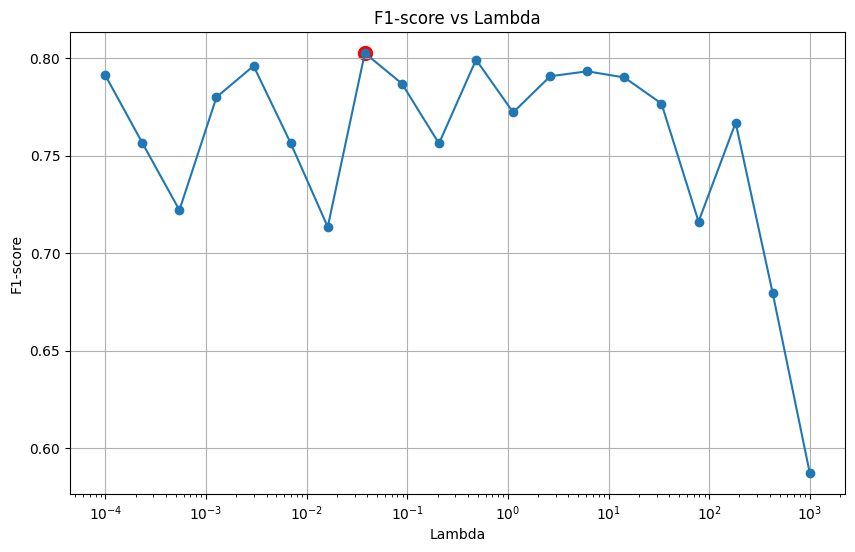

Best params: {'n_estimators': 20, 'max_depth': 6, 'min_samples_split': 5, 'sample_ratio': 0.8}
Best F1 macro score: 0.9286887528646396

Resultados para LDA
Matriz de Confusión:
 [[402  10   0]
 [ 52 340  88]
 [  0   1 463]]
Accuracy: 0.8886

Métricas por clase para LDA:


,Clase,Precision,Recall,F1
0,Clase 1,0.885,0.976,0.928
1,Clase 2,0.969,0.708,0.818
2,Clase 3,0.840,0.998,0.912


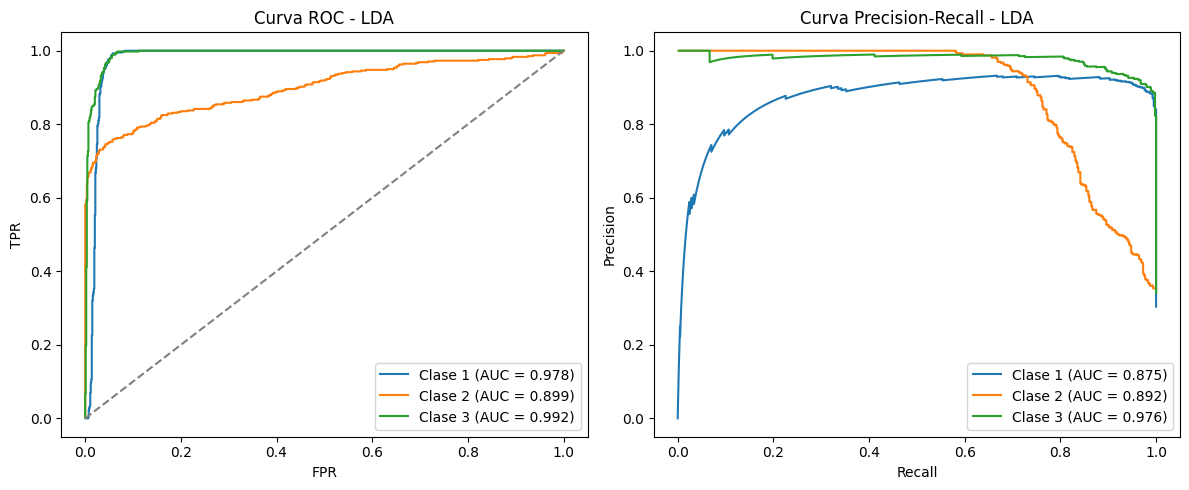


Model coefficients per class:

Class 0 coefficients:
--------------------------------------------------
poss                 | 0.03324
mp                   | 0.00969
raptor_total         | 0.03287
pace_impact          | -1.72473
--------------------------------------------------

Class 1 coefficients:
--------------------------------------------------
poss                 | 0.32645
mp                   | -0.69555
raptor_total         | -0.76738
pace_impact          | 0.39998
--------------------------------------------------

Class 2 coefficients:
--------------------------------------------------
poss                 | -0.35841
mp                   | 0.67848
raptor_total         | 0.70701
pace_impact          | 1.34048
--------------------------------------------------

Resultados para LogReg Softmax L2
Matriz de Confusión:
 [[394  18   0]
 [ 56 348  76]
 [  0  15 449]]
Accuracy: 0.8783

Métricas por clase para LogReg Softmax L2:


,Clase,Precision,Recall,F1
0,Clase 1,0.876,0.956,0.914
1,Clase 2,0.913,0.725,0.808
2,Clase 3,0.855,0.968,0.908


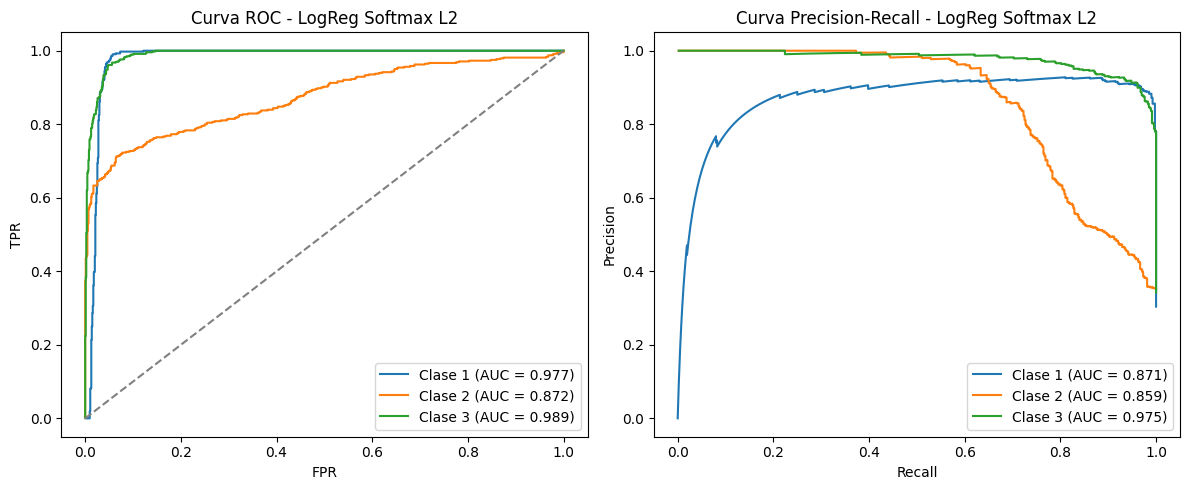


Resultados para Random Forest
Matriz de Confusión:
 [[398  14   0]
 [ 30 427  23]
 [  0  12 452]]
Accuracy: 0.9417

Métricas por clase para Random Forest:


,Clase,Precision,Recall,F1
0,Clase 1,0.930,0.966,0.948
1,Clase 2,0.943,0.890,0.915
2,Clase 3,0.952,0.974,0.963


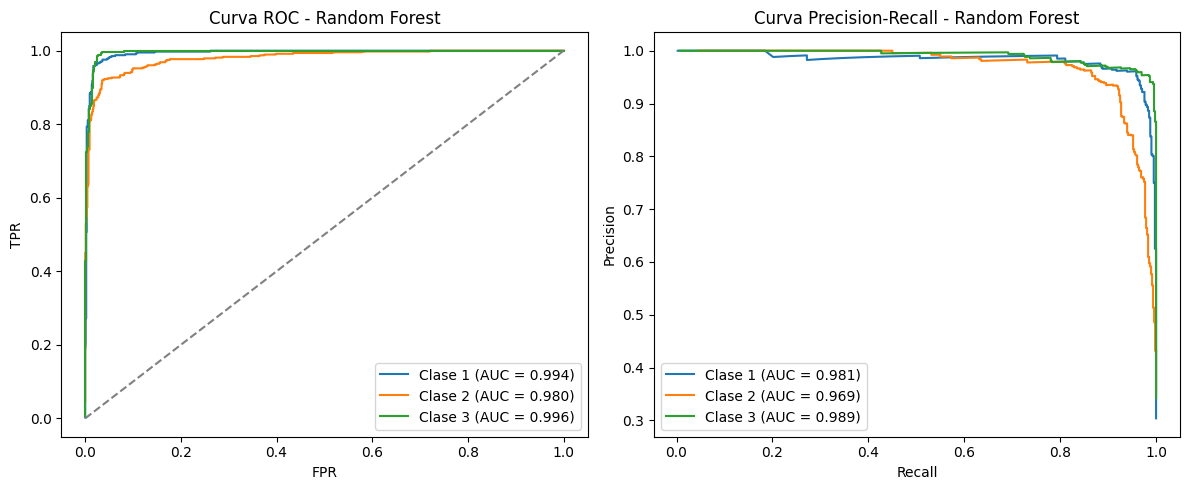


Tabla Comparativa de Modelos:


,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
0,LDA,0.888643,0.898138,0.893969,0.886338,0.956459,0.914555
1,LogReg Softmax L2,0.878319,0.881393,0.882994,0.876834,0.946116,0.901737
2,Random Forest,0.941740,0.941363,0.943247,0.941891,0.989815,0.979272


In [4]:
df = pd.read_csv('../data/raw/WAR_class_dev.csv')
df = df.drop(columns=['war_total'])

features = [col for col in df.columns if col != 'war_class']

train_df, val_df = train_val_split_df(df, val_size=0.2, seed=0)

feature_ranges = get_feature_ranges(train_df, numeric_features.drop(columns=[TARGET, 'pace_impact', 'raptor_total']), q1=0.1449, q3=0.7336)
display(feature_ranges)

train_df_imputed, val_df_imputed = process_data(train_df, categorical_columns, val_df=val_df, feature_ranges=feature_ranges, target=TARGET)

print("Train set después de imputación:")
display(train_df_imputed.head())
print("\nValidation set después de imputación:")
display(val_df_imputed.head())

y_train_encoded, class_to_int, int_to_class = encode_labels(train_df_imputed[TARGET].values)
y_val_encoded = np.array([class_to_int[label] for label in val_df_imputed[TARGET].values])

X_train_LDA, _ = prepare_data(train_df_imputed, features, TARGET, add_bias=False)
X_val_LDA, _ = prepare_data(val_df_imputed, features, TARGET, add_bias=False)

X_train_LR, _ = prepare_data(train_df_imputed, features, TARGET, add_bias=True)
X_val_LR, _ = prepare_data(val_df_imputed, features, TARGET, add_bias=True)

# class_names for graphics
n_classes = len(class_to_int)
class_names = [int_to_class[i] for i in range(n_classes)]


# Logistic Regression
lambdas = np.logspace(-4, 3, 20)

f1_scores = []
best_lambda = None
best_f1 = -1

for lmb in lambdas:
    model = LogisticRegressionL2(lambda_=lmb)
    model.fit(X_train_LR, y_train_encoded)
    y_probs = model.predict_proba(X_val_LR)
    y_pred = np.argmax(y_probs, axis=1)
    f1 = f1_score(y_val_encoded, y_pred)
    f1_scores.append(f1)
    
    if f1 > best_f1:
        best_f1 = f1
        best_lambda = lmb

print(f"Mejor lambda: {best_lambda}")
print(f"Mejor F1-score: {best_f1:.4f}")

# F1-score vs Lambda
plt.figure(figsize=(10, 6))
plt.plot(lambdas, f1_scores, marker='o')
plt.scatter([best_lambda], [best_f1], color='red', s=100, label='Mejor lambda')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('F1-score')
plt.title('F1-score vs Lambda')
plt.grid()
plt.show()


# Random Forest
param_grid = {
    'n_estimators': [5, 10,20],
    'max_depth': [3, 4, 6],
    'min_samples_split': [2, 5],
    'sample_ratio': [0.6, 0.8]
}
results = cross_validate_model(RandomForest, X_train_LR, y_train_encoded, param_grid)
print("Best params:", results["best_params"])
print("Best F1 macro score:", results["best_score"])


# Train models
models = {
    "LDA": LDA(),
    "LogReg Softmax L2": LogisticRegressionL2(lambda_ = best_lambda, multi_class='softmax'),
    "Random Forest": RandomForest(n_estimators=results["best_params"]["n_estimators"], max_depth=results["best_params"]["max_depth"], min_samples_split=results["best_params"]["min_samples_split"], sample_ratio=results["best_params"]["sample_ratio"])
}

for name, model in models.items():
    if name == "LDA":
        model.fit(X_train_LDA, y_train_encoded)
        y_pred = model.predict(X_val_LDA)
    else:
        model.fit(X_train_LR, y_train_encoded)
        if name == "LogReg Softmax L2":
            model.print__coef(features)
        y_pred = model.predict(X_val_LR)

    print(f"\nResultados para {name}")
    cm = confusion_matrix(y_val_encoded, y_pred, n_classes)
    print("Matriz de Confusión:\n", cm)

    acc = accuracy(y_val_encoded, y_pred)
    print(f"Accuracy: {acc:.4f}")

    prec, rec, f1 = precision_recall_fscore(y_val_encoded, y_pred, n_classes)
    metrics_df = pd.DataFrame({
        "Clase": [f"Clase {i+1}" for i in range(n_classes)],
        "Precision": [f"{prec[i]:.3f}" for i in range(n_classes)],
        "Recall": [f"{rec[i]:.3f}" for i in range(n_classes)],
        "F1": [f"{f1[i]:.3f}" for i in range(n_classes)]
    })

    print(f"\nMétricas por clase para {name}:")
    display(metrics_df)

    # ROC and PR curves
    if hasattr(model, 'predict_proba'):
        if name == "LDA":
            probs = model.predict_proba(X_val_LDA)
        else:
            probs = model.predict_proba(X_val_LR)
    elif name == "Random Forest":
        votes = np.array([[tree.predict_one(x) for tree in model.trees] for x in X_val_LR])
        probs = np.zeros((len(X_val_LR), n_classes))
        for i in range(len(X_val_LR)):
            vote_counts = Counter(votes[i])
            for cls, cnt in vote_counts.items():
                probs[i, cls] = cnt / model.n_estimators
    else:
        print(f"El modelo {name} no soporta probabilidades. Saltando curvas ROC y PR.")
        continue

    plot_pr_roc_curves(y_val_encoded, probs, name)


headers = ["Modelo", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "AUC-PR"]
val_sets = {
    "LDA": (X_val_LDA, y_val_encoded),
    "LogReg Softmax L2": (X_val_LR, y_val_encoded),
    "Random Forest": (X_val_LR, y_val_encoded)
}

res = resumen_metricas(models, val_sets, n_classes)

res_df = pd.DataFrame(res, columns=headers)

print("\nTabla Comparativa de Modelos:")
display(res_df)

# 2.4
Re-entrene los modelos utilizando todo el conjunto de desarrollo para ajustar los parámetros WAR_class_dev.csv, y evalúe las métricas de performance usando el conjunto de test WAR_class_test.csv.

{'poss': (np.float64(4.24), np.float64(9329.4)),
 'mp': (np.float64(0.23), np.float64(4264.46))}


[TEST] Resultados para LDA
Matriz de Confusión:
 [[478   5   0]
 [ 84 458  89]
 [  0   5 577]]
Accuracy: 0.8921

Métricas por clase para LDA:


,Clase,Precision,Recall,F1
0,Clase 1,0.851,0.990,0.915
1,Clase 2,0.979,0.726,0.833
2,Clase 3,0.866,0.991,0.925


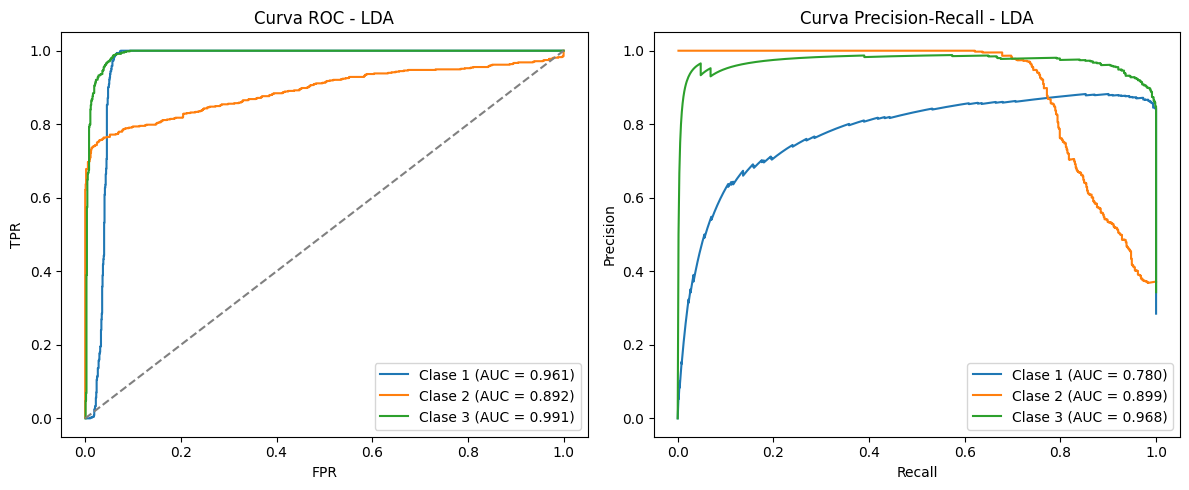


[TEST] Resultados para LogReg Softmax L2
Matriz de Confusión:
 [[469  14   0]
 [ 90 465  76]
 [  0  26 556]]
Accuracy: 0.8785

Métricas por clase para LogReg Softmax L2:


,Clase,Precision,Recall,F1
0,Clase 1,0.839,0.971,0.900
1,Clase 2,0.921,0.737,0.819
2,Clase 3,0.880,0.955,0.916


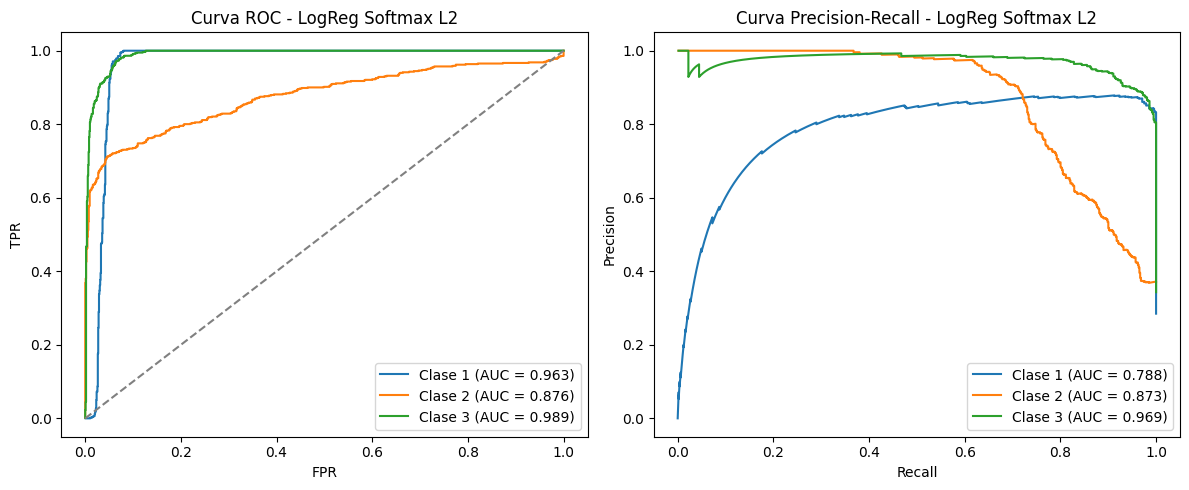


[TEST] Resultados para Random Forest
Matriz de Confusión:
 [[477   6   0]
 [ 47 556  28]
 [  0  12 570]]
Accuracy: 0.9452

Métricas por clase para Random Forest:


,Clase,Precision,Recall,F1
0,Clase 1,0.910,0.988,0.947
1,Clase 2,0.969,0.881,0.923
2,Clase 3,0.953,0.979,0.966


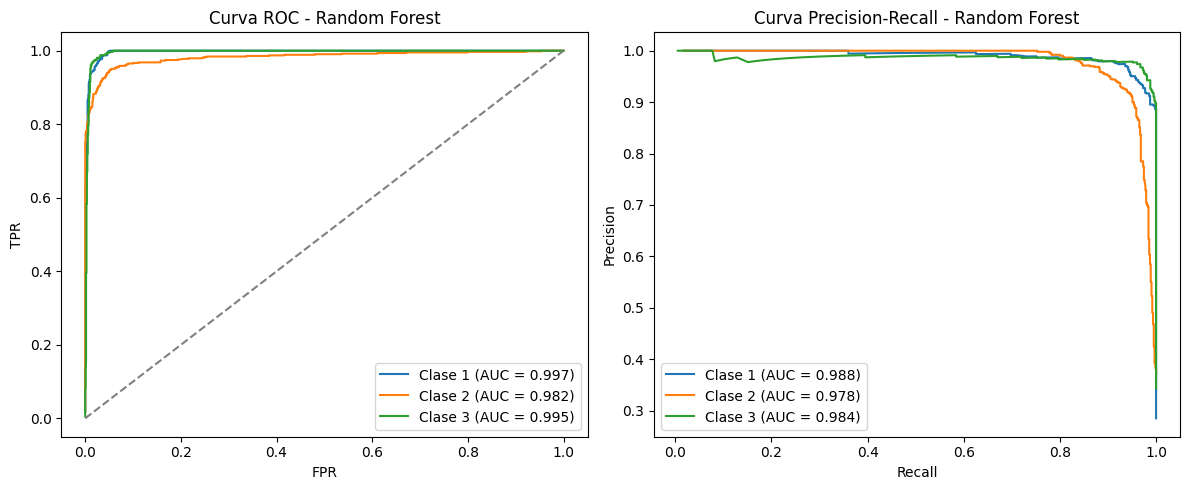


Tabla Comparativa de Modelos:


,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
0,LDA,0.892099,0.898511,0.902296,0.890999,0.948180,0.882128
1,LogReg Softmax L2,0.878538,0.879846,0.887755,0.878278,0.942615,0.876854
2,Random Forest,0.945165,0.944041,0.949367,0.945431,0.991400,0.983520


In [5]:
df_test = pd.read_csv('../data/raw/WAR_class_test.csv')
df_dev = pd.read_csv('../data/raw/WAR_class_dev.csv')

df_dev = df_dev.drop(columns=['war_total'])
df_test = df_test.drop(columns=['war_total'])

feature_ranges = get_feature_ranges(df_dev, numeric_features.drop(columns=[TARGET, 'pace_impact', 'raptor_total']), q1=0.1449, q3=0.7336)
display(feature_ranges)

df_dev_processed, df_test_processed = process_data(df_dev, categorical_columns, val_df=df_test, feature_ranges=feature_ranges, target=TARGET)

y_dev_encoded, class_to_int, int_to_class = encode_labels(df_dev_processed[TARGET].values)
y_test_encoded = np.array([class_to_int[label] for label in df_test_processed[TARGET].values])

X_dev_LDA, _ = prepare_data(df_dev_processed, features, TARGET, add_bias=False)
X_test_LDA, _ = prepare_data(df_test_processed, features, TARGET, add_bias=False)

X_dev_LR, _ = prepare_data(df_dev_processed, features, TARGET, add_bias=True)
X_test_LR, _ = prepare_data(df_test_processed, features, TARGET, add_bias=True)

n_classes = len(class_to_int)
class_names = [int_to_class[i] for i in range(n_classes)]

models_test = {
    "LDA": LDA(),
    "LogReg Softmax L2": LogisticRegressionL2(lambda_ = best_lambda, multi_class='softmax'),
    "Random Forest": RandomForest(n_estimators=results["best_params"]["n_estimators"], max_depth=results["best_params"]["max_depth"], min_samples_split=results["best_params"]["min_samples_split"], sample_ratio=results["best_params"]["sample_ratio"])
}

for name, model in models_test.items():
    if name == "LDA":
        model.fit(X_dev_LDA, y_dev_encoded)
        y_pred = model.predict(X_test_LDA)
    else:
        model.fit(X_dev_LR, y_dev_encoded)
        y_pred = model.predict(X_test_LR)

    print(f"\n[TEST] Resultados para {name}")
    cm = confusion_matrix(y_test_encoded, y_pred, n_classes)
    print("Matriz de Confusión:\n", cm)

    acc = accuracy(y_test_encoded, y_pred)
    print(f"Accuracy: {acc:.4f}")

    prec, rec, f1 = precision_recall_fscore(y_test_encoded, y_pred, n_classes)
    metrics_df = pd.DataFrame({
        "Clase": [f"Clase {i+1}" for i in range(n_classes)],
        "Precision": [f"{prec[i]:.3f}" for i in range(n_classes)],
        "Recall": [f"{rec[i]:.3f}" for i in range(n_classes)],
        "F1": [f"{f1[i]:.3f}" for i in range(n_classes)]
    })

    print(f"\nMétricas por clase para {name}:")
    display(metrics_df)

    # ROC y PR curves
    if hasattr(model, 'predict_proba'):
        if name == "LDA":
            probs = model.predict_proba(X_test_LDA)
        else:
            probs = model.predict_proba(X_test_LR)
    elif name == "Random Forest":
        votes = np.array([[tree.predict_one(x) for tree in model.trees] for x in X_test_LR])
        probs = np.zeros((len(X_test_LR), n_classes))
        for i in range(len(X_test_LR)):
            vote_counts = Counter(votes[i])
            for cls, cnt in vote_counts.items():
                probs[i, cls] = cnt / model.n_estimators
    else:
        print(f"El modelo {name} no soporta probabilidades. Saltando curvas ROC y PR.")
        continue

    plot_pr_roc_curves(y_test_encoded, probs, name)

val_sets_test = {
    "LDA": (X_test_LDA, y_test_encoded),
    "LogReg Softmax L2": (X_test_LR, y_test_encoded),
    "Random Forest": (X_test_LR, y_test_encoded)
}

res_test = resumen_metricas(models_test, val_sets_test, n_classes)

headers = ["Modelo", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "AUC-PR"]

res_df = pd.DataFrame(res_test, columns=headers)

print("\nTabla Comparativa de Modelos:")
display(res_df)

# 2.5
Analizar los resultados obtenidos y discutir cuál de los modelos llevaría a producción. Justificar la elección en base a las métricas observadas y al comportamiento del modelo. Además, compare las métricas de performance obtenidas en los incisos 2.3 y 2.4 . ¿Son parecidas? Es decir, ¿la estimación de métricas de error mediante validación/validación cruzada son parecidas a las métricas obtenidas sobre el conjunto de test?

Según los resultados del 2.3, **Random Forest** fue el modelo con mejor desempeño, alcanzando los valores más altos en todas las métricas (accuracy, precision, recall, F1-score, AUC ROC y AUC PR), lo que indica un excelente equilibrio entre sensibilidad y especificidad, logrando una clasificación precisa de tanto los casos positivos como los negativos, con alta confianza. En contraste, la **regresión logística multiclase** obtuvo el menor rendimiento, aunque junto con **LDA** mostró un desempeño competitivo pese a su simplicidad.

Si bien **Random Forest** fue claramente superior, modelos como **LDA** (con un F1-score de 0.89 frente al 0.94 de Random Forest) pueden ser preferibles en escenarios donde se prioricen la simplicidad, la interpretabilidad y la eficiencia computacional.

Los gráficos del 2.3 ilustran el desempeño de los modelos. En **Random Forest**, se observa que alcanza un AUC ROC de 0.99 y un AUC PR de 0.98 en la mayoría de sus clases, lo cual indica un rendimiento excepcional en la clasificación multiclase. Además, las curvas Precision-Recall (PR) presentan una forma homogénea entre clases: comienzan aproximadamente en el punto $(0, 1)$ y finalizan en $(1, 0)$. Este comportamiento uniforme se debe a que **Random Forest** produce distribuciones de probabilidad discretizadas y poco calibradas, resultado de la votación entre árboles. En consecuencia, los valores de probabilidad tienden a concentrarse cerca de 0 o 1, generando curvas PR más suaves y con la trayectoria esperada. 

Por otro lado, **LDA** presenta mayor variabilidad entre clases, siendo la clase 2 la de peor rendimiento. Esto se evidencia al observar que su curva ROC se aproxima más a la diagonal, lo que indica una menor capacidad discriminativa.

A diferencia de **Random Forest**, tanto **LDA** como **regresión logística multiclase** generan probabilidades calibradas y continuas, que permiten reflejar de forma más precisa la incertidumbre del modelo. En estos casos, se observa que la clase 2 presenta una curva PR con comportamiento más abrupto: inicia cerca de $(0, 0)$, asciende a un punto próximo a $(0.98, 0.9)$ y luego desciende hacia $(1, 0.3)$. Este patrón indica que el modelo identifica con alta certeza un subconjunto pequeño de instancias positivas (alta precision y buen recall inicial), pero al relajar el umbral de decisión, se incorporan numerosos falsos positivos, lo que deteriora la precision.

Este fenómeno puede explicarse por una combinación de factores: dificultad del modelo para separar correctamente esa clase en el espacio de características, posible desbalance en su frecuencia o una mayor superposición con otras clases. A diferencia de **Random Forest**, los modelos lineales como **LDA** y **regresión logística** son más sensibles a estas variaciones, lo cual se refleja en la forma de sus curvas PR.

En el punto 2.4 se reentrenaron todos los modelos utilizando el conjunto completo de desarrollo *WAR\_class\_dev* y se evaluaron sobre el conjunto de prueba *WAR\_class\_test*. Las métricas obtenidas se resumen en la tabla comparativa de modelos, y muestran una alta concordancia con las estimaciones obtenidas mediante validación, con diferencias leves en las métricas AUC PR. En particular, sobre el conjunto de test se obtuvo un AUC PR de 0.98 para **Random Forest**, 0.88 para **LDA** y 0.88 para **regresión logística**; mientras que en el conjunto de desarrollo los valores fueron 0.98, 0.91 y 0.90, respectivamente.

Los resultados en el conjunto de prueba reafirman las conclusiones anteriores. **Random Forest** fue nuevamente el modelo con mejor rendimiento, alcanzando valores cercanos a 0.94 o superiores en todas las métricas. Esto confirma su capacidad para generalizar correctamente y mantener un buen desempeño más allá del conjunto de validación.

La **regresión logística** volvió a ubicarse por debajo de los otros dos modelos, mientras que **LDA** logró una performance competitiva, destacándose especialmente en precision, recall y AUC ROC. Dado que **LDA** es considerablemente más simple que **Random Forest**, podría preferirse en situaciones donde la diferencia de rendimiento no justifique el uso de modelos más complejos.

En conclusión, llevaría a producción **Random Forest** debido a que fue el modelo con mejor capacidad predictiva tanto en validación como en prueba. No obstante, **LDA** mostró ser una alternativa simple y eficaz, especialmente en escenarios donde la interpretabilidad o los recursos computacionales limitados son factores determinantes.